<a href="https://colab.research.google.com/github/berradimeriemencg/DS2025/blob/main/ML_10_12_2025_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Bibliothèques importées.

2. Données chargées. Dimensions : (178, 14)
   Classes : ['class_0' 'class_1' 'class_2']

3. Ajout de NaN artificiels…
   Total NaN insérés : 156

4. Nettoyage (imputation)…
   NaN restants : 0

5. EDA…
   Statistiques descriptives (5 premières colonnes) :
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium
count  178.000000  178.000000  178.000000         178.000000  178.000000
mean    12.988989    2.319326    2.369382          19.535955   99.460674
std      0.782693    1.095054    0.264159           3.236698   13.643613
min     11.030000    0.740000    1.360000          10.600000   78.000000
25%     12.370000    1.630000    2.240000          17.425000   88.250000
50%     13.040000    1.845000    2.360000          19.500000   98.000000
75%     13.610000    2.982500    2.527500          21.500000  106.000000
max     14.830000    5.800000    3.230000          30.000000  162.000000


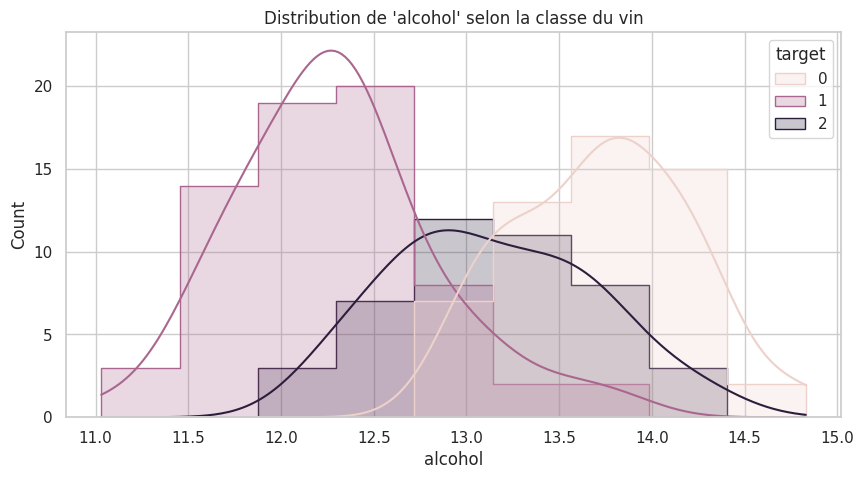

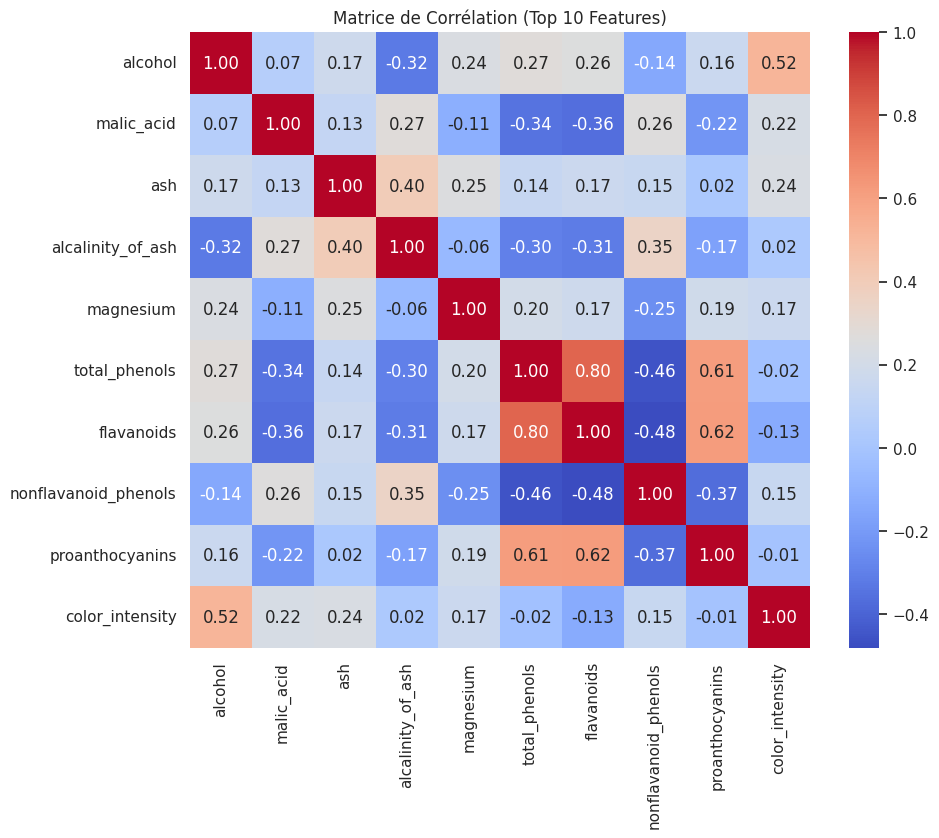


6. Split effectué :
   Train : 142
   Test  : 36

7. Entraînement du modèle...
   Modèle entraîné.

8. Évaluation…
   >>> Accuracy : 97.22%

   >>> Rapport de Classification :
              precision    recall  f1-score   support

     class_0       1.00      0.93      0.96        14
     class_1       0.93      1.00      0.97        14
     class_2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



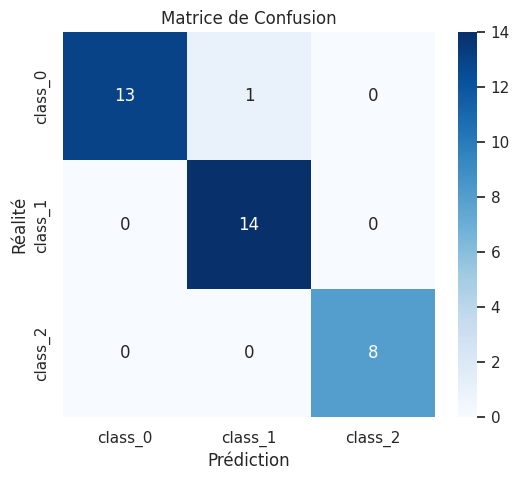


--- FIN DU SCRIPT ---


In [2]:
# ==============================================================================
# COURS DATA SCIENCE : CYCLE DE VIE COMPLET (SCRIPT PÉDAGOGIQUE - VERSION WINE)
# ==============================================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("1. Bibliothèques importées.\n")

# ------------------------------------------------------------------------------
# 2. CHARGEMENT DU DATASET (WINE QUALITY)
# ------------------------------------------------------------------------------
data = load_wine()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(f"2. Données chargées. Dimensions : {df.shape}")
print(f"   Classes : {data.target_names}\n")

# ------------------------------------------------------------------------------
# 3. SIMULATION DE DONNÉES SALES
# ------------------------------------------------------------------------------
print("3. Ajout de NaN artificiels…")

df_dirty = df.copy()
np.random.seed(42)

for col in df.columns[:-1]:
    df_dirty.loc[df_dirty.sample(frac=0.07).index, col] = np.nan

print(f"   Total NaN insérés : {df_dirty.isnull().sum().sum()}\n")

# ------------------------------------------------------------------------------
# 4. NETTOYAGE DES DONNÉES
# ------------------------------------------------------------------------------
print("4. Nettoyage (imputation)…")

X = df_dirty.drop("target", axis=1)
y = df_dirty["target"]

imputer = SimpleImputer(strategy="median")
X_clean = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f"   NaN restants : {X_clean.isnull().sum().sum()}\n")

# ------------------------------------------------------------------------------
# 5. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ------------------------------------------------------------------------------
print("5. EDA…")

# A. Statistiques descriptives
print("   Statistiques descriptives (5 premières colonnes) :")
print(X_clean.iloc[:, :5].describe())

# B. Histogramme d'une feature
plt.figure(figsize=(10, 5))
feature = "alcohol"
sns.histplot(df_dirty, x=feature, hue="target", kde=True, element="step")
plt.title(f"Distribution de '{feature}' selon la classe du vin")
plt.show()

# C. Heatmap corrélation
plt.figure(figsize=(10, 8))
corr = X_clean.iloc[:, :10].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de Corrélation (Top 10 Features)")
plt.show()

# ------------------------------------------------------------------------------
# 6. TRAIN / TEST SPLIT
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

print("\n6. Split effectué :")
print(f"   Train : {X_train.shape[0]}")
print(f"   Test  : {X_test.shape[0]}\n")

# ------------------------------------------------------------------------------
# 7. MODÉLISATION
# ------------------------------------------------------------------------------
print("7. Entraînement du modèle...")

model = RandomForestClassifier(n_estimators=120, random_state=42)
model.fit(X_train, y_train)

print("   Modèle entraîné.\n")

# ------------------------------------------------------------------------------
# 8. ÉVALUATION DU MODÈLE
# ------------------------------------------------------------------------------
print("8. Évaluation…")

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"   >>> Accuracy : {acc*100:.2f}%\n")

print("   >>> Rapport de Classification :")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.title("Matrice de Confusion")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.show()

print("\n--- FIN DU SCRIPT ---")
